# Complete Deep Learning Pipeline for BTC Trend Prediction
**Upgrades included in this version:**
1. **Deep Learning:** LSTM Network for Temporal Sequence processing
2. **Feature Engineering:** Rolling Volatility, RSI, MACD, and Order Flow approximations
3. **Position Sizing:** Kelly Criterion Allocation using Model Probabilities
4. **Regime Detection:** Hidden Markov Model (HMM) to discover hidden market regimes (Bull/Bear/Sideways) as features
5. **Deployment:** Serialization sequence for the Model, Scaler, and HMM filter.


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# HMM Import
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    import os
    print('Installing hmmlearn...')
    os.system('pip install hmmlearn')
    from hmmlearn.hmm import GaussianHMM


## 1. EDA & Data Loading

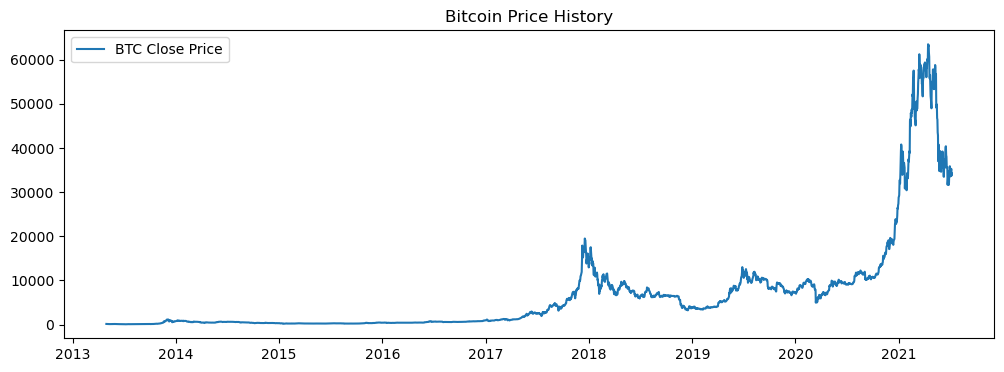

In [89]:
file_path = r"C:\Users\David\BTC-trend-prediction\data\raw\coin_Bitcoin.csv"
df = pd.read_csv(file_path, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.drop(columns=['SNo','Name','Symbol'], inplace=True, errors='ignore')

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Close'], label='BTC Close Price')
plt.title('Bitcoin Price History')
plt.legend()
plt.show()


## 2. Feature Engineering (Indicators & Order Flow)

In [90]:
# 1. Rolling Volatility
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol_20'] = df['Log_Ret'].rolling(window=20).std()

# 2. RSI (Relative Strength Index)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 3. MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 4. Order Flow (Approximations using Volume)
df['RVOL'] = df['Volume'] / df['Volume'].rolling(window=20).mean() # Relative Volume
df['OBV'] = (np.sign(df['Log_Ret']) * df['Volume']).cumsum() # On-Balance Volume
df['OBV_Slope'] = df['OBV'].diff(5) / df['OBV'].rolling(20).std()

# Target Variable (Trade at Open next day to avoid leakage)
horizon = 3
df['Future_3D_Ret'] = (df['Close'].shift(-horizon) - df['Open'].shift(-1)) / df['Open'].shift(-1)
df['Target'] = (df['Future_3D_Ret'] > 0.015).astype(int)

df.dropna(inplace=True)


## 3. Hidden Markov Model (Regime Detection)
We use an HMM to categorize the market into hidden states (Bear, Bull, Sideways) automatically. This will be fed as a feature to the LSTM.

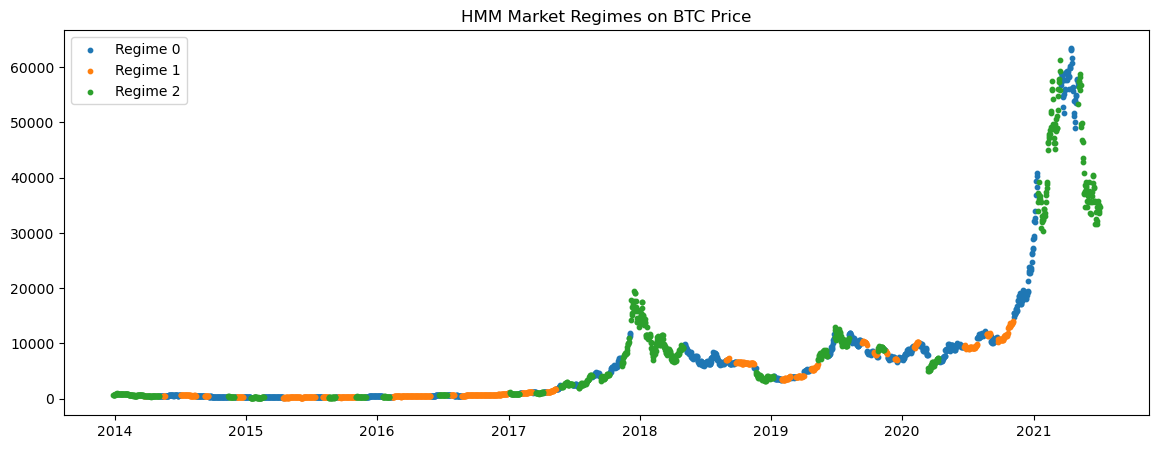

In [91]:
# HMM for Market Regime Detection
hmm_features = df[['Log_Ret', 'Vol_20']].dropna().values

# We look for 3 regimes
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(hmm_features)
df['HMM_Regime'] = hmm_model.predict(hmm_features)

# Visualize Regimes
plt.figure(figsize=(14, 5))
for i in range(hmm_model.n_components):
    regime_data = df[df['HMM_Regime'] == i]
    plt.scatter(regime_data['Date'], regime_data['Close'], label=f'Regime {i}', s=10)
plt.title('HMM Market Regimes on BTC Price')
plt.legend()
plt.show()

# One-hot encode the regime for the LSTM
df = pd.get_dummies(df, columns=['HMM_Regime'], prefix='Regime', dtype=int)


## 4. LSTM Sequencing & Chronological Split
Deep learning thrives on sequences. We will pass a rolling 14-day history (window) of our indicators to the LSTM.

In [92]:
features = ['Log_Ret', 'Vol_20', 'RSI_14', 'MACD', 'MACD_Signal', 'RVOL', 'OBV_Slope'] + [col for col in df.columns if 'Regime_' in col]
X_data = df[features].values
y_data = df['Target'].values

split_idx = int(len(df) * 0.8)
seq_length = 14

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length - 1])
    return np.array(X_seq), np.array(y_seq)

# --- Embargo: Drop 'horizon' days to prevent boundary leakage ---
X_train_raw = X_data[:split_idx - horizon]
y_train_raw = y_data[:split_idx - horizon]
X_test_raw = X_data[split_idx:]
y_test_raw = y_data[split_idx:]

test_dates = df['Date'].iloc[split_idx + seq_length - 1 : -1]
test_returns = df['Future_3D_Ret'].iloc[split_idx + seq_length - 1 : -1]

# Scale features (Fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Create Sequences
X_train, y_train = create_sequences(X_train_scaled, y_train_raw, seq_length)
X_test, y_test = create_sequences(X_test_scaled, y_test_raw, seq_length)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")


Train shapes: X=(2179, 14, 10), y=(2179,)
Test shapes: X=(536, 14, 10), y=(536,)


## 5. Model Architecture & Training

Training LSTM... this may take a moment.
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5557 - loss: 0.6795 - val_accuracy: 0.5994 - val_loss: 0.6821
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6235 - loss: 0.6568 - val_accuracy: 0.5627 - val_loss: 0.6767
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6136 - loss: 0.6521 - val_accuracy: 0.5841 - val_loss: 0.6993
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6405 - loss: 0.6363 - val_accuracy: 0.5566 - val_loss: 0.7010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6343 - loss: 0.6437 - val_accuracy: 0.6024 - val_loss: 0.6919
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6437 - loss: 0.6283 - val_accuracy: 0.5474 - val_loss: 0.7085
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6500 - loss: 0.6315 - val_accuracy: 0.6147 - val_loss: 0.7049
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 

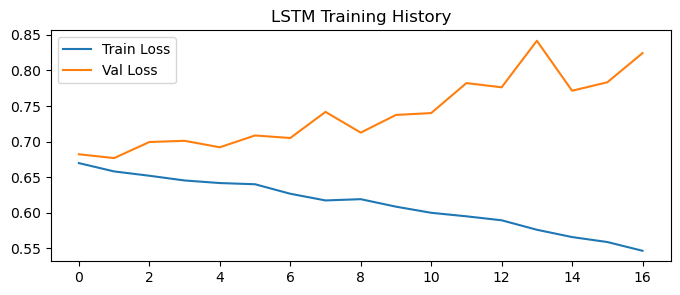

In [93]:
# Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, len(features))),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Probability Output
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training LSTM... this may take a moment.")
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.15, callbacks=[early_stop], verbose=1)

plt.figure(figsize=(8,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.legend()
plt.show()


## 6. Kelly Criterion Dynamic Sizing
Instead of blind percentages, the Kelly multiplier calculates statistically optimal bets: `f* = p - (1-p)/b`

In [94]:
# Predict Probabilities
test_probs = model.predict(X_test).flatten()
test_preds = (test_probs > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, test_preds))

# --- Kelly Criterion Sizing ---
# b = proportion of average win to average loss (Reward/Risk ratio)
train_ret = df['Future_3D_Ret'].iloc[:split_idx - horizon]
avg_win = train_ret[train_ret > 0].mean()
avg_loss = abs(train_ret[train_ret < 0].mean())
b = avg_win / avg_loss if avg_loss != 0 else 1.0
print(f"\nHistorical Reward/Risk Ratio (b): {b:.2f}")

# Calculate fractional Kelly Size: f* = p - (1-p)/b
kelly_f = test_probs - ((1 - test_probs) / b)

# Apply Half-Kelly for safety (standard practice to avoid blowing up due to model uncertainty)
half_kelly = np.clip(kelly_f / 2, 0, 1) # bound between 0% and 100%

backtest_df = pd.DataFrame({
    'Date': test_dates.values[:len(half_kelly)],
    'Actual_Return': test_returns.values[:len(half_kelly)],
    'Prob_Up': test_probs,
    'Kelly_Allocation': half_kelly
})


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.91      0.70       295
           1       0.61      0.17      0.26       241

    accuracy                           0.58       536
   macro avg       0.59      0.54      0.48       536
weighted avg       0.59      0.58      0.50       536


Historical Reward/Risk Ratio (b): 1.08


## 7. Strategy Backtest vs Buy & Hold

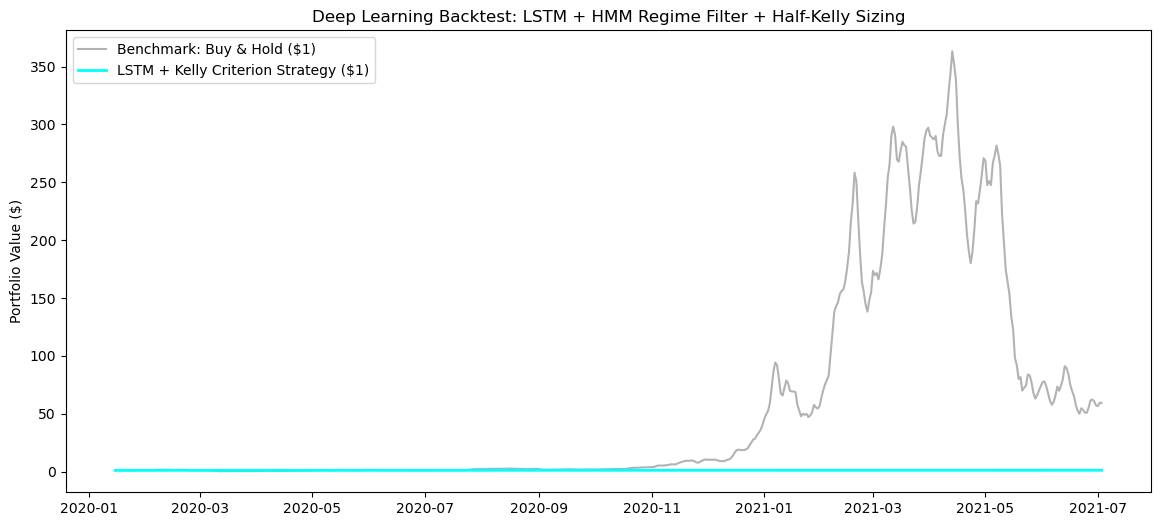

Final Benchmark Value: $59.30
Final Strategy Value: $1.06


In [95]:
initial_capital = 1.00

# 1. Benchmark: Buy & Hold
backtest_df['Benchmark'] = initial_capital * (1 + backtest_df['Actual_Return']).cumprod()

# 2. Strategy: Kelly Criterion Sizing
backtest_df['Strategy_Ret'] = backtest_df['Kelly_Allocation'] * backtest_df['Actual_Return']
backtest_df['Kelly_Portfolio'] = initial_capital * (1 + backtest_df['Strategy_Ret']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(backtest_df['Date'], backtest_df['Benchmark'], label='Benchmark: Buy & Hold ($1)', color='gray', alpha=0.6)
plt.plot(backtest_df['Date'], backtest_df['Kelly_Portfolio'], label='LSTM + Kelly Criterion Strategy ($1)', color='cyan', linewidth=2)

plt.title('Deep Learning Backtest: LSTM + HMM Regime Filter + Half-Kelly Sizing')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()

print(f"Final Benchmark Value: ${backtest_df['Benchmark'].iloc[-1]:.2f}")
print(f"Final Strategy Value: ${backtest_df['Kelly_Portfolio'].iloc[-1]:.2f}")


## 8. Deployment

In [96]:
import os
models_dir = r"C:\Users\David\BTC-trend-prediction\models"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

model.save(r'C:\Users\David\BTC-trend-prediction\models\lstm_trend_model.keras')
joblib.dump(scaler, r'C:\Users\David\BTC-trend-prediction\models\scaler.pkl')
joblib.dump(hmm_model, r'C:\Users\David\BTC-trend-prediction\models\hmm_regime_model.pkl')

print("Pipeline deployment artifacts saved successfully to the /models directory.")


Pipeline deployment artifacts saved successfully to the /models directory.
